## 🧩 Hierarchical Clustering

### 🔹 1. Agglomerative Clustering (Bottom-Up)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
# Data Sederhana: Pendapatan dan Pengeluaran
data = np.array([
    [15, 16], [16, 18], [18, 14], [45, 50], [50, 55], 
    [52, 58], [85, 90], [90, 95], [88, 92]
])

In [4]:
# Agar lebih jelas, buatlah dataframe dengan label
df = pd.DataFrame(data, columns=['Pendapatan', 'Pengeluaran'])
df

,Pendapatan,Pengeluaran
0,15,16
1,16,18
2,18,14
3,45,50
4,50,55
5,52,58
6,85,90
7,90,95
8,88,92


💡 Kasus:
- Kita ingin mengelompokkan data pelanggan ke dalam **3 segmen** berdasarkan **pendapatan** dan **pengeluaran** mereka.

#### 🔍 Langkah-langkah Implementasi:

1. Dendrogram untuk Visualisasi Struktur Hierarkis  
Sebelum melakukan klastering, kita akan membuat dendrogram untuk melihat struktur pengelompokan secara bertahap.

In [5]:
# Linkage matrix (menghitung jarak antar data)
linked = linkage(data, method='ward')  # Ward method minimizes variance

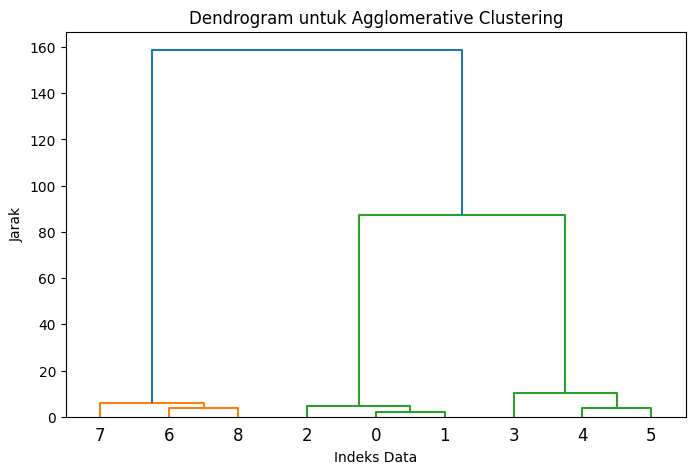

In [7]:
# Visualisasi Dendrogram
plt.figure(figsize=(8, 5))
dendrogram(linked)
plt.title('Dendrogram untuk Agglomerative Clustering')
plt.xlabel('Indeks Data')
plt.ylabel('Jarak')
plt.show()

2. Agglomerative Clustering (Clustering Sesungguhnya)  
Sekarang, kita akan menerapkan Agglomerative Clustering dan memotong dendrogram untuk mendapatkan 3 klaster.

In [9]:
# Agglomerative Clustering
agg_clust = AgglomerativeClustering(n_clusters=3, linkage='ward')
clusters = agg_clust.fit_predict(data)

In [11]:
# Menambahkan hasil klaster ke dataframe
df['Cluster'] = clusters
df

,Pendapatan,Pengeluaran,Cluster
0,15,16,2
1,16,18,2
2,18,14,2
3,45,50,0
4,50,55,0
5,52,58,0
6,85,90,1
7,90,95,1
8,88,92,1


#### 🔄 Hasil Visualisasi Klaster

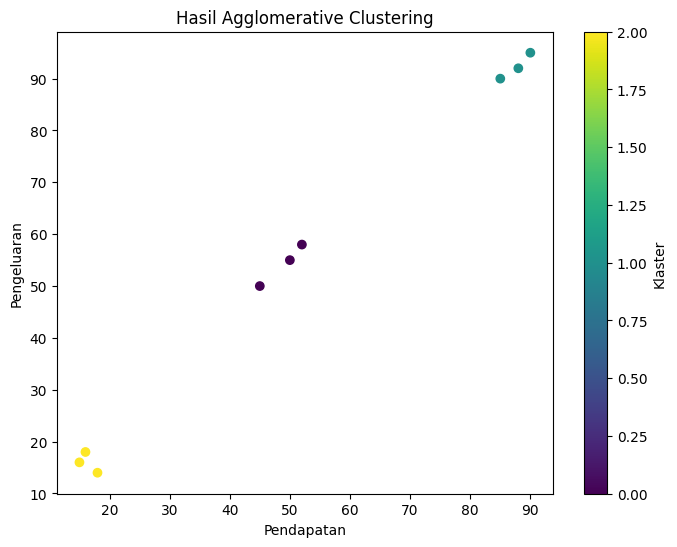

In [12]:
# Visualisasi hasil klaster
plt.figure(figsize=(8, 6))
plt.scatter(df['Pendapatan'], df['Pengeluaran'], c=df['Cluster'], cmap='viridis')
plt.xlabel('Pendapatan')
plt.ylabel('Pengeluaran')
plt.title('Hasil Agglomerative Clustering')
plt.colorbar(label='Klaster')
plt.show()

### 🧩 Penjelasan Implementasi:
Linkage Matrix:
- Fungsi linkage() digunakan untuk menghitung jarak antar titik menggunakan berbagai metode (misalnya, "ward", "single", atau "complete").
- Ward linkage adalah metode yang meminimalkan jumlah kuadrat jarak antar titik dalam klaster, yang sering kali memberikan hasil klaster yang lebih seimbang.

Dendrogram:
- Dendrogram menunjukkan proses penggabungan klaster, di mana sumbu vertikal menunjukkan jarak atau perbedaan antara dua klaster yang digabung. Ketika kamu melihat dendrogram, kamu bisa memilih ketinggian tertentu untuk memotong pohon dan mendapatkan jumlah klaster yang diinginkan.


Agglomerative Clustering:
- n_clusters=3 memastikan kita mendapatkan 3 klaster.
- affinity='euclidean' berarti kita menggunakan jarak Euclidean untuk mengukur kedekatan antar data.
- linkage='ward' memastikan metode Ward linkage digunakan dalam proses penggabungan klaster.

### 🔸 2. Divisive Clustering (Top-Down)